In [ ]:
import os
import gc 
import torch
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as transforms


# Initialize model with 4 out labels
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 4)
print(model)

# Define the device
try:
    device = "mps"
    model = model.to(device)
except:
    print(("Abort training on CPU..."))
    device = "cpu"

# Set the directory paths
directories = ["./Data/brain_tumor_4variants/Training",
               "./Data/brain_tumor_4variants2/Training"]

# Initialize empty lists to store the data
data = []

# Define the label mappings for the second dataset
label_mapping = {
    "no_tumor": 0,
    "notumor": 0,
    "glioma_tumor": 1,
    "glioma": 1,
    "meningioma_tumor": 2,
    "meningioma": 2,
    "pituitary_tumor": 3,
    "pituitary": 3
}

# Iterate through the directories
for directory in directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

class BrainTumorDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.data_frame = data_frame
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_path = self.data_frame.iloc[idx, 0]
        image = Image.open(img_path).convert("RGB")
        label = self.data_frame.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label


def compute_dataset_normalize_vals(image_paths, image_size=(224, 224)):
    """Return mean and std computed across the entire training image collection."""
    sum_ = torch.zeros(3)
    sum_sq = torch.zeros(3)
    count = 0
    norm_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    for img_path in image_paths:
        img = Image.open(img_path).convert("RGB")
        img_tensor = norm_transform(img)
        sum_ += img_tensor.mean(dim=[1, 2])
        sum_sq += (img_tensor ** 2).mean(dim=[1, 2])
        count += 1

    mean = sum_ / count
    var = sum_sq / count - mean ** 2
    std = torch.sqrt(torch.clamp(var, min=1e-6))
    return mean, std

train_image_paths = [path for path, _ in data]
m, s = compute_dataset_normalize_vals(train_image_paths)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=m, std=s),
    transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
])

# mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225] imagenet

btd1 = BrainTumorDataset(data_frame=dataset, transform=transform)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# make dataloader test
test_directories = ["./Data/brain_tumor_4variants/Testing"]

# Initialize empty lists to store the data
data = []

# Iterate through the test directories
for directory in test_directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            # Get a list of all .jpg files in the subdirectory
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            
            # Append the data to data
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

# Create the datasets using the DataFrames created earlier
btd2 = BrainTumorDataset(data_frame=dataset, transform=transform)

In [5]:
# make dataloader validator
val_directories = ["./Data/brain_tumor_4variants2/Testing"]

# Initialize empty lists to store the data
data = []

# Iterate through the validation directories
for directory in val_directories:
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            # Get a list of all .jpg files in the subdirectory
            file_list = [file for file in os.listdir(
                subdir_path) if file.endswith(".jpg")]
            
            # Append the data to data
            data.extend([(os.path.join(subdir_path, file),
                          label_mapping[subdir]) for file in file_list])

# Create the datasets as pandas DataFrames
dataset = pd.DataFrame(
    data, columns=["Image_Path", "Label"])

# Create the datasets using the DataFrames created earlier
btd3 = BrainTumorDataset(data_frame=dataset, transform=transform)

Epoch 1/10, Training Loss: 0.035
Epoch 1/10, Validation Loss: 1.95
Epoch 1/10, Validation Accuracy: 74.873%
New best model saved at epoch 1
Epoch 2/10, Training Loss: 0.011
Epoch 2/10, Validation Loss: 2.3
Epoch 2/10, Validation Accuracy: 73.35%
Epoch 3/10, Training Loss: 0.007
Epoch 3/10, Validation Loss: 2.228
Epoch 3/10, Validation Accuracy: 73.604%
Epoch 4/10, Training Loss: 0.004
Epoch 4/10, Validation Loss: 2.296
Epoch 4/10, Validation Accuracy: 74.112%
Epoch 5/10, Training Loss: 0.003
Epoch 5/10, Validation Loss: 2.234
Epoch 5/10, Validation Accuracy: 73.604%
Epoch 6/10, Training Loss: 0.003
Epoch 6/10, Validation Loss: 2.479
Epoch 6/10, Validation Accuracy: 74.112%
Early stopping triggered. Best model was from epoch 1
Loaded best model from epoch 1


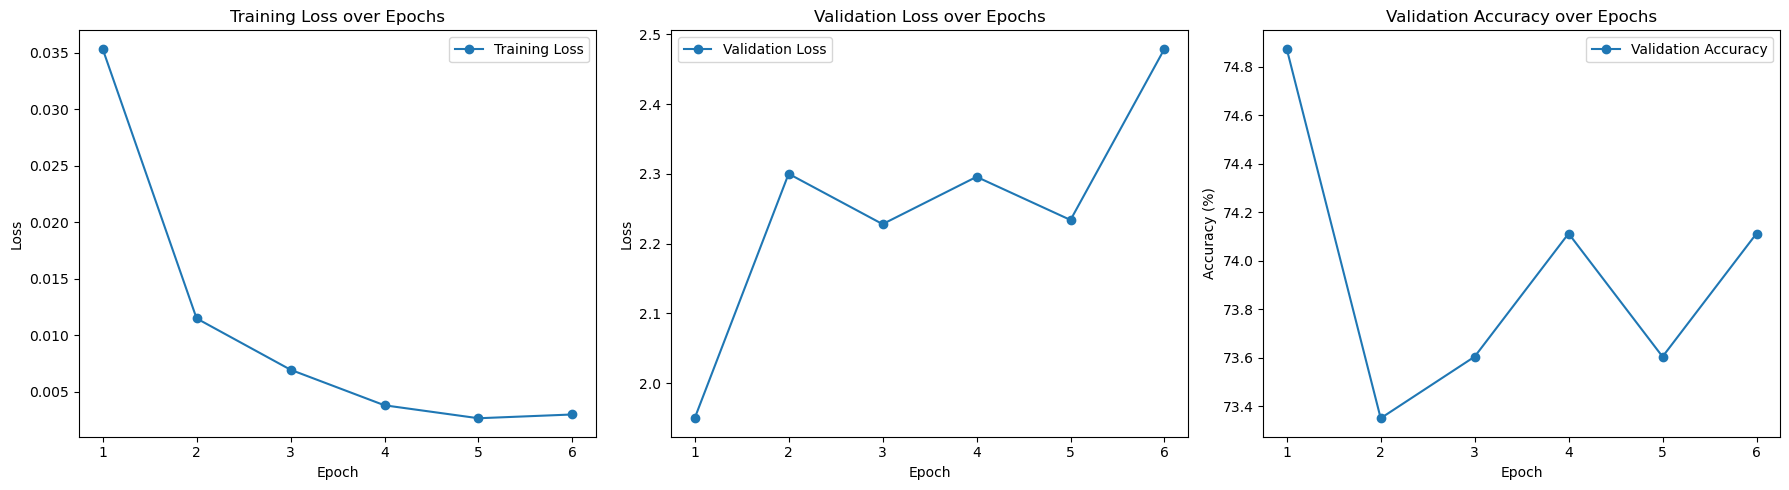

In [31]:
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

device = "mps"

# training pipeline 
trainloader = DataLoader(batch_size=32, shuffle=True, dataset=btd1)
valloader = DataLoader(batch_size=32, shuffle=False, dataset=btd2)

train_losses = []
val_losses = []
val_accuracies = []
best_accuracy = 0.00
epochs_without_improvement = 0
early_stopping_patience = 5
epochs = 10
criterion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0002, weight_decay=1e-4)
#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
model = model.to(device)

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {round(avg_train_loss,3)}")

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(valloader)
    val_losses.append(avg_val_loss)
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    #scheduler.step(accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {round(avg_val_loss,3)}")
    print(f"Epoch {epoch+1}/{epochs}, Validation Accuracy: {round(accuracy, 3)}%")

    # Model checkpointing
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_without_improvement = 0
        print(f"New best model saved at epoch {epoch+1}")
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= early_stopping_patience:
        print(
            f"Early stopping triggered. Best model was from epoch {best_epoch+1}")
        break

# Load the best model after training
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch+1}")

# Plotting the performance
plt.figure(figsize=(18, 5))

# Plot training loss
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses,
            marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

# Plot validation loss
plt.subplot(1, 3, 2)
plt.plot(range(1, len(val_losses) + 1), val_losses,
            marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss over Epochs')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 3, 3)
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies,
            marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
    # Validation phase
    testloader = DataLoader(batch_size=32, shuffle=False, dataset=btd3)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Final accuracy: {accuracy}")

Final accuracy: 97.63539282990084


In [ ]:
from datetime import date
# when happy save to ...
d = date.today()
dt = str(d.month) + str(d.year)
torch.save(model.state_dict(), f"./Models/resnet18/{model.__class__.__name__}_mri__{dt}_02.pth")

In [24]:
import os
import gc 
import torch
#import gradio as gr
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# load model
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("./Models/resnet18/ResNet_mri__62026.pth", weights_only=True))

<All keys matched successfully>

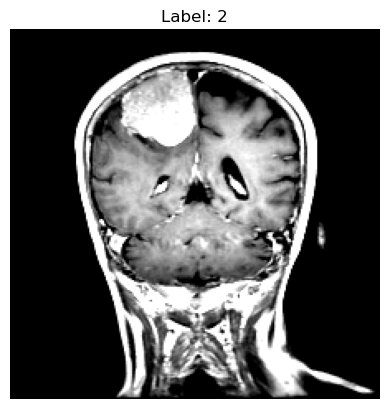

Probabilities: tensor([[2.0624e-06, 8.3459e-06, 9.9998e-01, 4.5965e-06]])
Prediction: 2
Label: 2


In [70]:


device = "cpu"
model = model.to(device)

def eval_perform(model, dataset):
    # Set the model to evaluation mode
    model.eval()

    # Pick a random image from the dataset
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]
    # Add batch dimension and move to device
    image = image.unsqueeze(0).to(device)

    # Run the model on the image
    with torch.no_grad():
        logits = model(image)

    # Calculate probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Display the image
    image_np = image.squeeze(0).cpu().numpy().transpose((1, 2, 0))
    
    plt.imshow(image_np)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

    return probabilities, label

probabilities, label = eval_perform(model, btd3)
print("Probabilities:", probabilities)
_, prediction = torch.max(probabilities.data, 1)
print("Prediction:", int(prediction))
print("Label:", label)